In [44]:
#importing packages, need to install before running if using new environment or computer
import numpy as np
from cellpose import models, core, io, plot, utils
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
import pandas as pd
import seaborn as sns
# from skimage.measure import label, regionprops

In [45]:
io.logger_setup()

creating new log file
2025-11-06 13:58:19,300 [INFO] WRITING LOG OUTPUT TO C:\Users\b1810\.cellpose\run.log
2025-11-06 13:58:19,302 [INFO] 
cellpose version: 	4.0.7 
platform:       	win32 
python version: 	3.11.14 
torch version:  	2.7.1+cu118
2025-11-06 13:58:19,302 [INFO] 
cellpose version: 	4.0.7 
platform:       	win32 
python version: 	3.11.14 
torch version:  	2.7.1+cu118


creating new log file
2025-11-06 13:58:19,300 [INFO] WRITING LOG OUTPUT TO C:\Users\b1810\.cellpose\run.log
2025-11-06 13:58:19,302 [INFO] 
cellpose version: 	4.0.7 
platform:       	win32 
python version: 	3.11.14 
torch version:  	2.7.1+cu118
2025-11-06 13:58:19,302 [INFO] 
cellpose version: 	4.0.7 
platform:       	win32 
python version: 	3.11.14 
torch version:  	2.7.1+cu118


(<Logger cellpose.io (INFO)>, WindowsPath('C:/Users/b1810/.cellpose/run.log'))

In [46]:
#checks for gpu access, error if no gpu and you should use cpu mode instead
if core.use_gpu()==False:
    raise ImportError("No GPU access, change your runtime"

SyntaxError: incomplete input (2337547824.py, line 3)

In [47]:
directory = 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001'
files = io.get_image_files(directory, mask_filter=[], look_one_level_down=True)

In [48]:


all_files = []
directory = 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001'
files = io.get_image_files(directory, mask_filter=[], look_one_level_down=True)
all_files.extend(files)

# directory = 'C:/Users/labadmin/Documents/BZ-X800/Chris/Psychatg02_07112025/S+B+_w1/W001/'
# files = io.get_image_files(directory, mask_filter=[], look_one_level_down=True)
# all_files.extend(files)
# directory = 'C:/Users/labadmin/Documents/BZ-X800/Chris/Psychatg02_07112025/B-S-_w1/W001/'
# files = io.get_image_files(directory, mask_filter=[], look_one_level_down=True)
# all_files.extend(files)
# directory = 'C:/Users/labadmin/Documents/BZ-X800/Chris/Psychatg02_07112025/B+_w2/W001/'
# files = io.get_image_files(directory, mask_filter=[], look_one_level_down=True)
# all_files.extend(files)
# directory = 'C:/Users/labadmin/Documents/BZ-X800/Chris/Psychatg02_07112025/B+_w1/W001/'
# files = io.get_image_files(directory, mask_filter=[], look_one_level_down=True)
# all_files.extend(files)

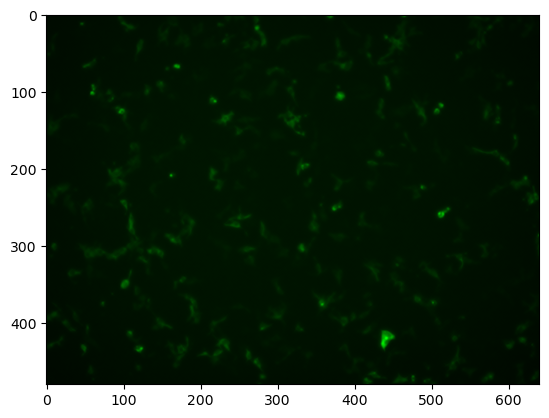

In [49]:
img = mpimg.imread(all_files[0])
plt.imshow(img)

In [50]:
all_files

['C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00001\\HM_W001_P00001_CH2.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00001\\HM_W001_P00001_CH4.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00001\\HM_W001_P00001_Overlay.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00002\\HM_W001_P00002_CH2.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00002\\HM_W001_P00002_CH4.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00002\\HM_W001_P00002_Overlay.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00003\\HM_W001_P00003_CH2.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00003\\HM_W001_P00003_CH4.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psyc

In [51]:
filtered_files = list(filter(lambda s: "Overlay" in s, all_files))

In [52]:
filtered_files

['C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00001\\HM_W001_P00001_Overlay.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00002\\HM_W001_P00002_Overlay.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00003\\HM_W001_P00003_Overlay.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00004\\HM_W001_P00004_Overlay.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00005\\HM_W001_P00005_Overlay.tif',
 'C:/Users/b1810/Desktop/coding/Psychatg02_07112025/Psychatg02_07112025/B+_w1/W001\\P00006\\HM_W001_P00006_Overlay.tif']

In [61]:
img_collection = []
selected_channels = [1, 2]
#what channels should i select
print("loading images")
imgs = [io.imread(filtered_files[i]) for i in trange(len(filtered_files))]
for img in imgs:
    img_selected_channels = np.zeros_like(img)
    img_selected_channels[:,:,:len(selected_channels)] = img[:,:,selected_channels]
    img_collection.append(img_selected_channels)

loading images


loading images


100%|██████████| 6/6 [00:00<00:00, 108.95it/s]


In [70]:
img_collection[0].shape

(480, 640, 3)

In [71]:
import matplotlib.pyplot as plt
import numpy as np

def show_channels(img_cl, titles=None, cmap='gray'):
    assert img_cl.ndim == 3, "Expect (H, W, C)"
    H, W, C = img_cl.shape
    cols = min(C, 4)
    rows = int(np.ceil(C / cols))
    plt.figure(figsize=(4*cols, 4*rows))
    for c in range(C):
        plane = img_cl[..., c]
        # percentile-based contrast stretch
        p1, p99 = np.percentile(plane, (1, 99))
        plane_disp = np.clip((plane - p1) / (p99 - p1 + 1e-9), 0, 1)
        ax = plt.subplot(rows, cols, c+1)
        ax.imshow(plane_disp, cmap=cmap)
        title = titles[c] if titles and c < len(titles) else f"Channel {c}"
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_channels(img_cl)

NameError: name 'img_cl' is not defined

In [63]:
from skimage.color import label2rgb, rgb2gray
from skimage import img_as_ubyte, io, filters, morphology

'masks' in globals(), type(globals().get('masks')), (len(masks) if 'masks' in globals() else None)

# print("saving masks")
# for i in trange(len(filtered_files)):
#     f = filtered_files[i]
#     io.imsave(Path(f).parent /  ("nuclear_mask" + ".tif"), masks[i])
#     #print(Path(f).parent /  ("nuclear_mask" + ".tif"))
#     #break

#     rgb = label2rgb(masks[i], bg_label=0, bg_color=(0, 0, 0))  # float in [0,1]
#     rgb_u8 = img_as_ubyte(rgb)                             # convert to uint8
#     io.imsave(Path(f).parent / "mask_labels_rgb.tif", rgb_u8)

(False, NoneType, None)

In [64]:
len(filtered_files)

6

In [ ]:
len(img_collection)

In [ ]:
model = models.CellposeModel(gpu=True)

In [ ]:
flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_collection, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

In [ ]:
len(masks)

In [ ]:
from skimage.color import label2rgb, rgb2gray
from skimage import img_as_ubyte, io, filters, morphology

print("saving masks")
for i in trange(len(filtered_files)):
    f = filtered_files[i]
    io.imsave(Path(f).parent /  ("nuclear_mask" + ".tif"), masks[i])
    #print(Path(f).parent /  ("nuclear_mask" + ".tif"))
    #break

    rgb = label2rgb(masks[i], bg_label=0, bg_color=(0, 0, 0))  # float in [0,1]
    rgb_u8 = img_as_ubyte(rgb)                             # convert to uint8
    io.imsave(Path(f).parent / "mask_labels_rgb.tif", rgb_u8)

In [ ]:
img

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    axes[i].imshow(imgs[0][:,:,i], cmap="gray")
    axes[i].set_title(f"Channel {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    axes[i].imshow(imgs[18][:,:,i])
    axes[i].set_title(f"Channel {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    axes[i].imshow(imgs[-1][:,:,i])
    axes[i].set_title(f"Channel {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(12, 5))
plot.show_segmentation(fig, imgs[-1], masks[-1], flows[-1][0])
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
#Let's look at the overlay
img = io.imread(files[-1])
img.shape

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    axes[i].imshow(img[:,:,i], cmap="gray")
    axes[i].set_title(f"Channel {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#For nuclei segmentation, let's just choose GFP and DAPI channel
selected_channels = [1, 2]
img_selected_channels = np.zeros_like(img)
img_selected_channels[:,:,:len(selected_channels)] = img[:,:,selected_channels]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i in range(2):
    axes[i].imshow(img_selected_channels[:,:,i], cmap="gray")
    axes[i].set_title(f"Channel {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
model = models.CellposeModel(gpu=True)

In [ ]:
flow_threshold = 0.4
cellprob_threshold = 0.0
tile_norm_blocksize = 0

masks, flows, styles = model.eval(img_selected_channels, batch_size=32, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})

In [ ]:
fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()

In [ ]:
ch2_files = list(filter(lambda s: "CH2" in s, files))
ch2_files

In [ ]:
labels = io.get_label_files(ch2_files, mask_filter='_seg.npy')
labels

In [ ]:
from cellpose.io import imread

valid_imgs = []
bad_files = []

for f in files:
    try:
        img = imread(f)
        if img is not None and hasattr(img, 'ndim') and img.ndim >= 2:
            valid_imgs.append(img)
        else:
            bad_files.append(f)
    except Exception as e:
        print(f"Error reading {f}: {e}")
        bad_files.append(f)

print(f"Loaded {len(valid_imgs)} valid images.")
print(f"Skipped {len(bad_files)} files.")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io
from cellpose.io import imread

io.logger_setup()

model = models.CellposeModel(gpu=True)

# list of files
# PUT PATH TO YOUR FILES HERE
directory = 'C:/Users/labadmin/Documents/BZ-X800/Chris/Psychatg02_07112025/S+B+_w2/W001/P00001'
files = io.get_image_files(directory, mask_filter=[], look_one_level_down=True)

imgs = [imread(f) for f in files]
nimg = len(imgs)

masks, flows, styles = model.eval(imgs)



In [ ]:
directory = 'Users/labadmin/Documents/BZ-X800/Chris/Psychatg02_07112025'

In [ ]:
files = io.get_image_files(directory, mask_filter=[], look_one_level_down=True)

In [ ]:
files

In [ ]:
import nd2

In [ ]:
for x in files:
    if x.endswith(".nd2"):
        header = x.split("/")[-1].split('//')[-1].split(".nd2")[0]
        new_file = header + ".ome.tiff"
        #print(new_file)
        nd2.nd2_to_tiff(x, str(directory + "/" + new_file))

In [ ]:
nd2.nd2_to_tiff??

#